First we need to download and clean the data for use. We need to encode our descriptive columns of geography and gender, drop our id column, and standardize the columns with numbers (credit_score, estimated_salary, age, balance, tenure, and products_number).

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gauravtopre/bank-customer-churn-dataset")
# Load the dataset
df = pd.read_csv('/kaggle/input/bank-customer-churn-dataset/Bank Customer Churn Prediction.csv')
# Check original column names and values
print("Original Data")
print(df.head())
#  Drop irrelevant customer_id
df = df.drop(columns=['customer_id'])

# Drop duplicates and fill empty cells of dataframe.
df = df.drop_duplicates()
df = df.dropna()

#  Convert country names and gender to numbers.
df_encode = pd.get_dummies(df, columns =['country', 'gender'])

# Z-score scale credit_score, estimated_salary, age, balance, tenure, and products_number.
scaler = StandardScaler()
cols_to_scale = ['credit_score', 'estimated_salary', 'age', 'balance', 'products_number', 'tenure']
df_encode[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
# Print head to ensure data is cleaned.
print("Dropped Column Data")
print(df.head())

print("Encoded Data")
print(df_encode.head())

Using Colab cache for faster access to the 'bank-customer-churn-dataset' dataset.
Original Data
   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  
Dropped Column Data
   cred

Now that we have cleaned the data and finished pre-processing it, we can create some plots to help get an idea about what may be causing customer churn. The heatmap gives us a general overview of what impacts the churn, the countplot and KDE plot provide insight into the more specific correlation of amount of products owned and age with churn status.

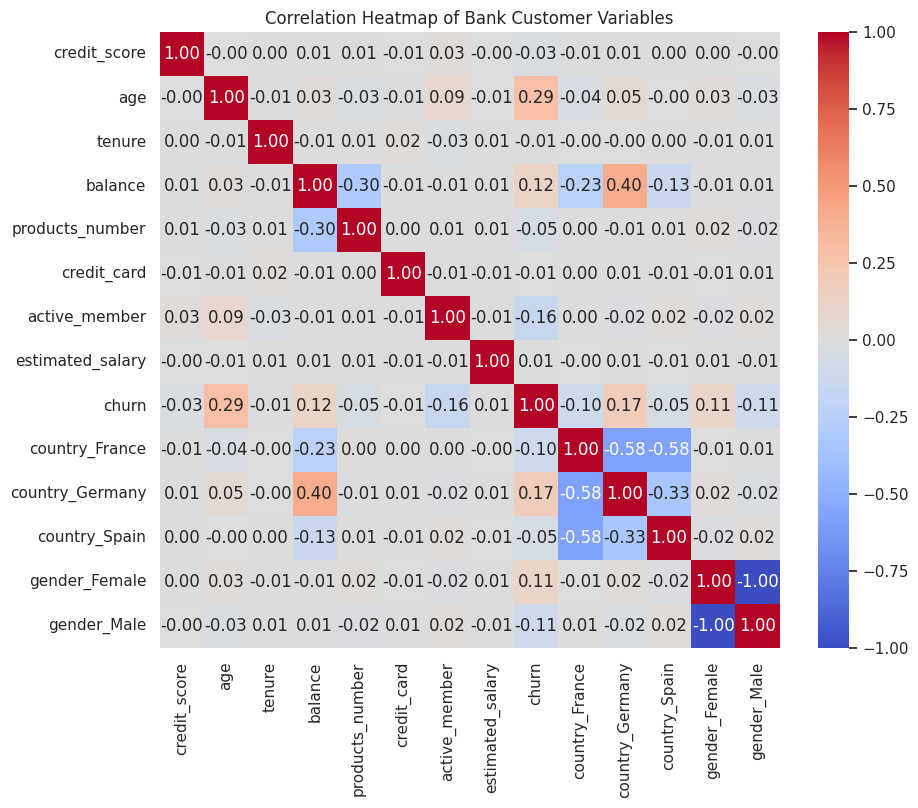

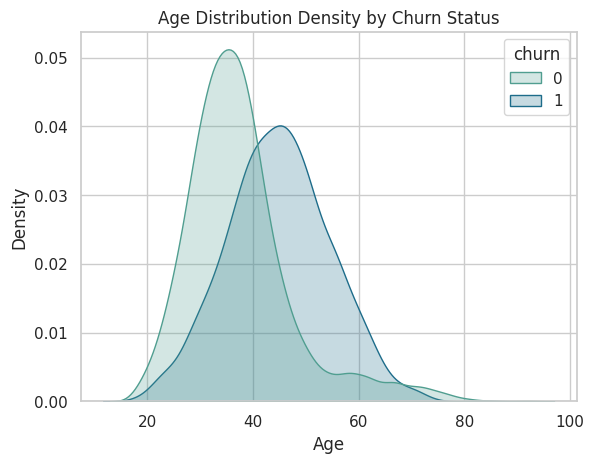

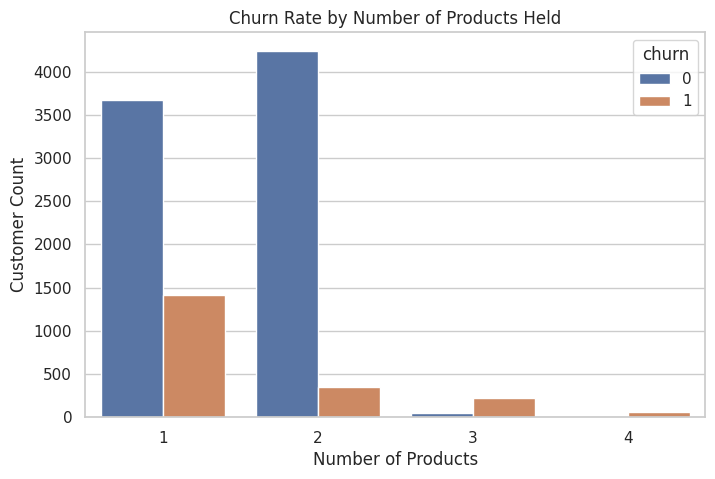

churn             0    1  Total
products_number                
3                46  220    266
4                 0   60     60
Total            46  280    326


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Correlation Heatmap
# This helps evaluate the relationship between different variables.
plt.figure(figsize=(10, 8))
sns.heatmap(df_encode.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Bank Customer Variables")
plt.show()


# KDE plot showing distribution of age by churn status
sns.kdeplot(data=df, x='age', hue='churn', fill=True, common_norm=False, palette='crest')
plt.title('Age Distribution Density by Churn Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

# Countplot of churned customers by number of products they hold
plt.figure(figsize=(8, 5))
sns.countplot(x='products_number', hue='churn', data=df)
plt.title("Churn Rate by Number of Products Held")
plt.xlabel("Number of Products")
plt.ylabel("Customer Count")
plt.show()

# Table of unchurned/churned customers correlated with customers owning 3 or 4 products
Three_or_four_product_customers = df[df['products_number'].isin([3, 4])]
churn_table = pd.crosstab(
    Three_or_four_product_customers['products_number'],
    Three_or_four_product_customers['churn'],
    margins=True,
    margins_name="Total"
)
print(churn_table)

After looking at the general trends, we can see that there is a strong correlation between inactivity and churn. To make it easier for analysis, we need to take the inverse of that variable to analyze inactivity rather than activity. We also can establish our training split and testing split for the Logistic Regression and Decision Tree models.

In [ ]:
from sklearn.model_selection import train_test_split
# Easier analysis if instead of looking at protective feature activity
# we actually look at the dangerous feature of inactivity
df_encode['inactive_member'] = 1 - df_encode['active_member']
df_encode = df_encode.drop(columns=['active_member'])
# Isolate the features from the target variable
X = df_encode.drop('churn', axis=1)
y = df_encode['churn']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# We print dimensions to ensure our split was successful
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (8000, 13)
Testing features shape: (2000, 13)


Now that we have split our data, we can create and test our models. We need to examine the results to see how these models preform, so we output the results.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import numpy as np


# We need to create and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

# Generate our predictions
log_preds = log_reg.predict(X_test)

# Output our logistic regression baseline for analysis.
print("Logistic Regression Baseline")
print(f"Accuracy: {accuracy_score(y_test, log_preds):.4f}\n")
print(classification_report(y_test, log_preds))
odds_ratios = pd.DataFrame({
    'Feature': X.columns,
    'Odds Ratio': np.exp(log_reg.coef_[0])
}).sort_values(by='Odds Ratio', ascending=False)

print("\nLogistic Regression Odds Ratios")
print(odds_ratios)

# We need to create and train our Decision Tree
tree_model = DecisionTreeClassifier(random_state=42, max_depth=5)
tree_model.fit(X_train, y_train)

# Generate our predictions
tree_preds = tree_model.predict(X_test)

# Output stats of our decision tree
print("Decision Tree Model")
print(f"Accuracy: {accuracy_score(y_test, tree_preds):.4f}\n")
print(classification_report(y_test, tree_preds))

Logistic Regression Baseline
Accuracy: 0.8080

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000


Logistic Regression Odds Ratios
             Feature  Odds Ratio
12   inactive_member    2.795868
1                age    2.086989
8    country_Germany    1.187936
3            balance    1.175324
6   estimated_salary    1.048724
2             tenure    0.980029
4    products_number    0.931896
5        credit_card    0.930762
0       credit_score    0.917822
10     gender_Female    0.757088
9      country_Spain    0.546358
7     country_France    0.523134
11       gender_Male    0.448474
Decision Tree Model
Accuracy: 0.8560

              precision    recall  f1-score   support

           0       0.86      0.97     

We can see here that our model has a decently high accuracy, but a low recall for churned customers. It should be our priority to capture as many churned customers as possible, we need to adjust the balancing of the class_weight to capture more of the churning customers.

Balanced Logistic Regression
Accuracy: 0.7135

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000

             Feature  Odds Ratio
12   inactive_member    2.418404
1                age    2.222302
8    country_Germany    1.534435
3            balance    1.192241
10     gender_Female    1.126340
6   estimated_salary    1.052005
2             tenure    0.981448
4    products_number    0.943782
5        credit_card    0.932868
0       credit_score    0.916497
9      country_Spain    0.711580
7     country_France    0.672784
11       gender_Male    0.652196


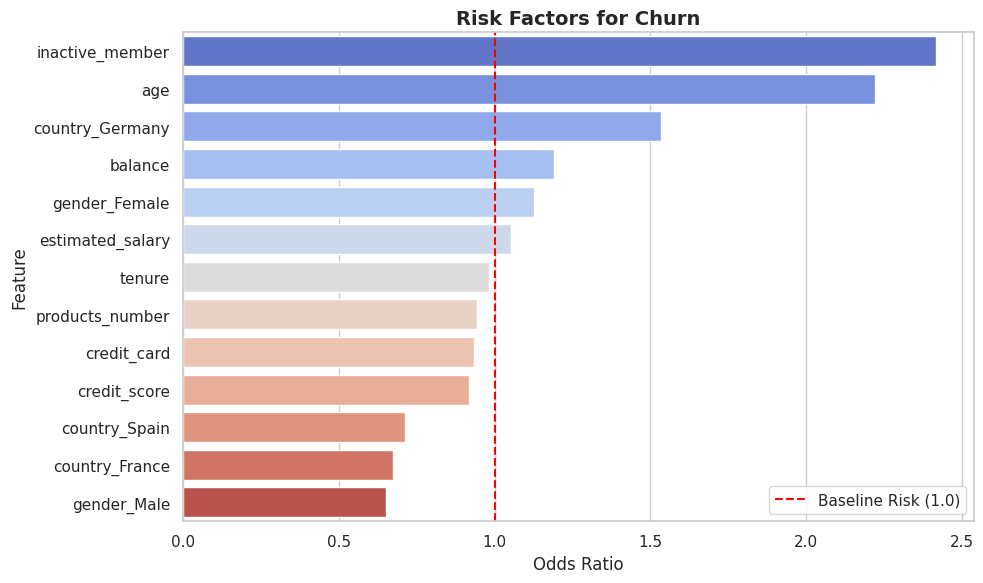


Balanced Decision Tree
Accuracy: 0.7705

              precision    recall  f1-score   support

           0       0.93      0.77      0.84      1593
           1       0.46      0.77      0.58       407

    accuracy                           0.77      2000
   macro avg       0.69      0.77      0.71      2000
weighted avg       0.83      0.77      0.79      2000



In [ ]:
# We need to create and train our new balanced models of Logistic Regression and Decision Tree
log_reg_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
tree_balanced = DecisionTreeClassifier(random_state=42, max_depth=5, class_weight='balanced')

# Fit the balanced models
log_reg_balanced.fit(X_train, y_train)
tree_balanced.fit(X_train, y_train)

# Generate our new balanced predictions
log_preds_bal = log_reg_balanced.predict(X_test)
tree_preds_bal = tree_balanced.predict(X_test)

# Output results for Logistic Regression
print("Balanced Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, log_preds_bal):.4f}\n")
print(classification_report(y_test, log_preds_bal))
balanced_odds_ratios = pd.DataFrame({
    'Feature': X.columns,
    'Odds Ratio': np.exp(log_reg_balanced.coef_[0])
}).sort_values(by='Odds Ratio', ascending=False)
print(balanced_odds_ratios)

plt.figure(figsize=(10, 6))
sns.barplot(x='Odds Ratio', y='Feature', data=balanced_odds_ratios, palette='coolwarm', hue ='Feature')
plt.axvline(x=1.0, color='red', linestyle='--', label='Baseline Risk (1.0)')
plt.title('Risk Factors for Churn', fontsize=14, fontweight='bold')
plt.xlabel('Odds Ratio', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.legend()
plt.tight_layout()

# Display plot
plt.show()
# Output Decision Tree Results
print("\nBalanced Decision Tree")
print(f"Accuracy: {accuracy_score(y_test, tree_preds_bal):.4f}\n")
print(classification_report(y_test, tree_preds_bal))


Our accuracy has dropped slightly, but our recall has increased tremendously. Our logistic regression model and decision tree model capture 70% and 77% of the churning customers respectively. This is a significant improvement, our decision tree could be used to catch roughly 3/4 of churning customers.